🚀 MEMULAI PROSES A/B TESTING (UJI HIPOTESIS STATISTIK)
✅ Dataset Finansial berhasil dimuat!

📋 Ringkasan Sampel Data:
• Jumlah sampel Kelompok Hemat (Group A) : 6408 transaksi
• Jumlah sampel Kelompok Boros (Group B) : 641 transaksi
• Rata-rata nominal per transaksi [Hemat]   : Rp 84,379.68
• Rata-rata nominal per transaksi [Boros]   : Rp 83,560.06

📊 HASIL ANALISIS STATISTIK WELCH'S T-TEST
• T-Statistic : 0.5577
• P-Value     : 5.7721e-01

📝 KESIMPULAN UJI HIPOTESIS:
Karena P-Value (5.7721e-01) >= alpha (0.05), maka kita GAGAL MENOLAK Hipotesis Nol (H0).
Artinya: TIDAK ADA perbedaan yang signifikan secara statistik pada nominal pengeluaran (jumlah) antara kondisi keuangan Hemat dan Boros.


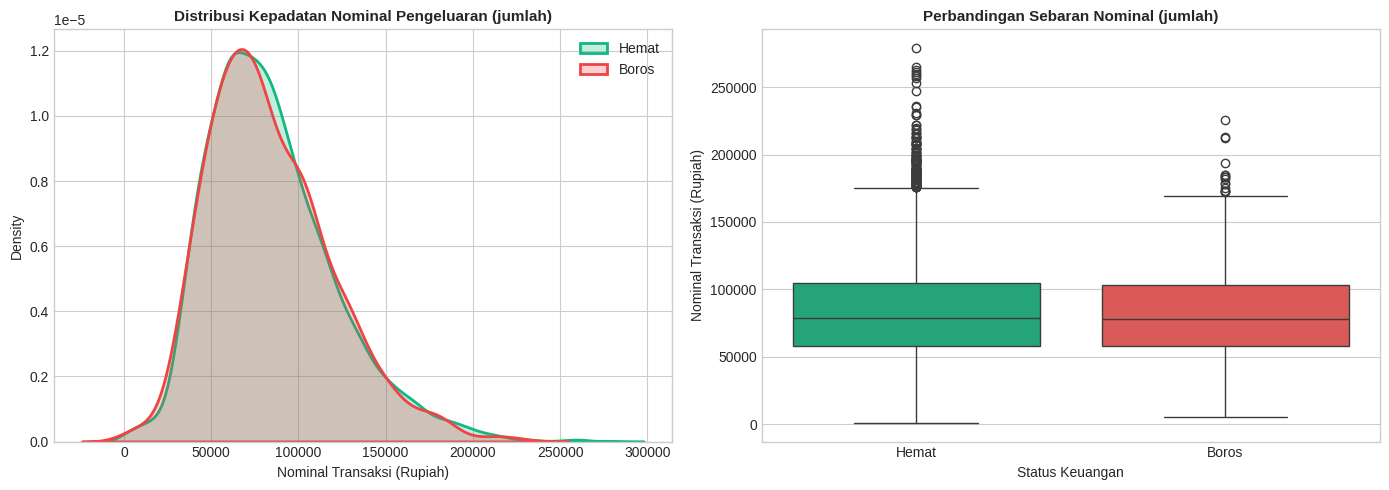

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("🚀 MEMULAI PROSES A/B TESTING (UJI HIPOTESIS STATISTIK)")
print("=" * 60)

# 1. Load Dataset hasil clustering kemarin
file_path = 'DATASET_KEUANGAN_CLUSTERED.xlsx'
try:
    df = pd.read_excel(file_path)
    print("✅ Dataset Finansial berhasil dimuat!")
except FileNotFoundError:
    print(f"❌ Error: File {file_path} tidak ditemukan.")

# Filter hanya untuk transaksi uang keluar saja biar adil pengujiannya
df_pengeluaran = df[df['tipe_label'] == 'Keluar'].copy()

# 2. Definisikan Group A (Hemat) dan Group B (Boros)
group_a_label = 'Hemat'
group_b_label = 'Boros'
metric = 'jumlah' # Menguji nominal transaksi pengeluaran

# Memisahkan data transaksi pengeluaran berdasarkan status label
group_a = df_pengeluaran[df_pengeluaran['status_label'] == group_a_label][metric]
group_b = df_pengeluaran[df_pengeluaran['status_label'] == group_b_label][metric]

print(f"\n📋 Ringkasan Sampel Data:")
print(f"• Jumlah sampel Kelompok {group_a_label} (Group A) : {len(group_a)} transaksi")
print(f"• Jumlah sampel Kelompok {group_b_label} (Group B) : {len(group_b)} transaksi")
print(f"• Rata-rata nominal per transaksi [{group_a_label}]   : Rp {group_a.mean():,.2f}")
print(f"• Rata-rata nominal per transaksi [{group_b_label}]   : Rp {group_b.mean():,.2f}")

# 3. Melakukan T-Test (Independent Two-Sample T-Test)
# Menggunakan Welch's t-test (equal_var=False) karena jumlah sampel dan variasi data berbeda
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print("\n" + "="*50)
print("📊 HASIL ANALISIS STATISTIK WELCH'S T-TEST")
print("="*50)
print(f"• T-Statistic : {t_stat:.4f}")
print(f"• P-Value     : {p_value:.4e}")

# 4. Kesimpulan dan Interpretasi Hasil
alpha = 0.05 # Tingkat signifikansi 5%
print("\n📝 KESIMPULAN UJI HIPOTESIS:")
if p_value < alpha:
    print(f"Karena P-Value ({p_value:.4e}) < alpha ({alpha}), maka kita MENOLAK Hipotesis Nol (H0).")
    print(f"Artinya: Terdapat PERBEDAAN YANG SIGNIFIKAN secara statistik pada nominal pengeluaran ({metric}) antara kondisi keuangan {group_a_label} dan {group_b_label}.")
else:
    print(f"Karena P-Value ({p_value:.4e}) >= alpha ({alpha}), maka kita GAGAL MENOLAK Hipotesis Nol (H0).")
    print(f"Artinya: TIDAK ADA perbedaan yang signifikan secara statistik pada nominal pengeluaran ({metric}) antara kondisi keuangan {group_a_label} dan {group_b_label}.")

# 5. Visualisasi Distribusi dan Boxplot Pengujian
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi (KDE Plot agar lebih halus)
sns.kdeplot(group_a, color='#10B981', fill=True, label=group_a_label, ax=ax1, linewidth=2)
sns.kdeplot(group_b, color='#EF4444', fill=True, label=group_b_label, ax=ax1, linewidth=2)
ax1.set_title(f'Distribusi Kepadatan Nominal Pengeluaran ({metric})', fontsize=11, weight='bold')
ax1.set_xlabel('Nominal Transaksi (Rupiah)')
ax1.set_ylabel('Density')
ax1.legend()

# Plot 2: Boxplot untuk melihat sebaran dan Outlier
plot_df = pd.DataFrame({
    'Status Keuangan': [group_a_label]*len(group_a) + [group_b_label]*len(group_b),
    'Nominal Transaksi': list(group_a) + list(group_b)
})
# Tambahkan hue='Status Keuangan' dan legend=False agar warnanya pas dan bebas dari peringatan
sns.boxplot(
    x='Status Keuangan',
    y='Nominal Transaksi',
    data=plot_df,
    hue='Status Keuangan',       # SAKTI: Menentukan penanda warna berdasarkan grup status
    palette=['#10B981', '#EF4444'],
    legend=False,                 # Mematikan double legend otomatis bawaan seaborn
    ax=ax2
)
ax2.set_title(f'Perbandingan Sebaran Nominal ({metric})', fontsize=11, weight='bold')
ax2.set_ylabel('Nominal Transaksi (Rupiah)')

plt.tight_layout()
plt.show()

Insight :
- Berdasarkan hasil pengujian Welch's T-Test, diperoleh nilai $P\text{-Value} = 5.7721 \times 10^{-1}$ (0,5772). Karena nilai $P\text{-Value} \ge \alpha$ (0,05), maka keputusan uji statistik adalah Gagal Menolak Hipotesis Nol ($H_0$). Hal ini membuktikan bahwa secara statistik tidak terdapat perbedaan yang signifikan pada rata-rata nominal per transaksi (jumlah) antara kelompok status keuangan Hemat dan Boros.

- Rata-rata nominal per transaksi pada kelompok Hemat tercatat sebesar Rp 84.379,68, sedangkan pada kelompok Boros tercatat sebesar Rp 83.560,06. Kemiripan angka rata-rata ini menunjukkan bahwa profil nilai transaksi harian pengguna memiliki kecenderungan konstan pada batas psikologis di bawah Rp 100.000, baik dalam kondisi keuangan terkendali maupun kritis.

- Perbedaan fundamental antara kedua kondisi finansial terletak pada volume atau frekuensi transaksi, bukan pada besaran nominal objek belanja. Kelompok data Hemat mencakup total 6.408 transaksi, sementara kelompok Boros hanya mencakup 641 transaksi dalam basis data. Hal ini mengindikasikan bahwa status keuangan "Boros" murni dipicu oleh akumulasi tingginya frekuensi transaksi berskala kecil yang terjadi secara berulang dalam satu periode (efek akumulasi pengeluaran impulsif).

- Berdasarkan visualisasi grafik Kernel Density Estimate (KDE) dan Boxplot, kedua kelompok data menunjukkan bentuk kurva distribusi yang saling berimpit (overlapping) pada rentang Rp 0 hingga Rp 200.000 dengan kemiringan positif (positive skewness). Keberadaan data pencilan (outliers) yang memanjang ke arah kanan pada kedua kelompok membuktikan bahwa transaksi bernominal besar (di atas Rp 600.000) bersifat anomali dan bukan merupakan representasi umum dari perilaku pengeluaran harian pengguna.

- Oleh karena akar permasalahan dari kondisi keuangan "Boros" bersumber dari faktor kuantitas transaksi dan bukan nilai nominal transaksi, maka strategi intervensi yang direkomendasikan adalah pembatasan kuota frekuensi transaksi (transaction capping). Pengguna disarankan untuk melakukan pembatasan jumlah maksimal aktivitas transaksi per minggu, khususnya untuk pos pengeluaran dalam kelompok Klaster 1 (Pengeluaran Impulsif/Keinginan).